# Testes com a avaliação de amostras no QGIS

- Extensão de amostras como plugin do QGIS usando SOM como base;
- Para que o problema não fique apenas técnico e limitado a algumas técnicas específicas;
- Inserir a parte de classificação + avaliação no plugin após a seleção das amostras;

## Etapas:

 - Seleção de área e período;
 - Visualização da imagem (Busca de imagem via STAC);
 - Seleção de grade SOM e atributos;
 - Avaliação do agrupamento;
 - Definição da taxa de amostras por classe;
 - Extração das séries temporais;
 - Classificação multiclasse com MLP;

In [41]:
import pystac_client
import numpy as np
import xarray as xr
from simplecube import simple_cube
import matplotlib.pyplot as plt
from som import SOMNetwork
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from datetime import datetime, timedelta
import rioxarray
import rasterio
from rasterio.features import shapes
import geopandas as gpd
import pandas as pd
from shapely.geometry import shape, Point, MultiPolygon
from sklearn.metrics import silhouette_score

def count_days(date, days_ = 7, sub = False):
    start_date = datetime(
        int(date[:4]),
        int(date[5:7]),
        int(date[8:])
    )
    if sub:
        end_date = start_date - timedelta(days=days_)
    else:
        end_date = start_date + timedelta(days=days_)
    end_date = end_date.strftime("%Y-%m-%d")
    return end_date

## Seleção de área e período

In [2]:
stac_url = "https://data.inpe.br/bdc/stac/v1"
service = pystac_client.Client.open(stac_url)
collections = {}

for coll in service.get_collections():
    collections[coll.title] = coll.id

print(list(collections.keys()))

['CBERS-4A/MUX - Level-4-DN', 'CBERS-4/WFI - Level-4-DN', 'CBERS-4A/WFI 3M Paraíba State Mosaic', 'Landsat 6M São Paulo State Mosaic', 'S2 3M Paraiba State Mosaic', 'S2 6M Yanomami Indigenous Territory Mosaic', 'Sentinel-3/OLCI - Level-1B Full Resolution', 'MODIS-Aqua Monthly Rrs - OC-SMART AC', 'CBERS-4A/WPM - Multispectral and Panchromatic Bands Fusioned', 'CBERS-4A/WFI - Level-2-DN', 'Sentinel-1 - Level-1 - Interferometric Wide Swath Ground Range Detected High Resolution', 'Sentinel-2/MSI - Level-2A - Data Cube - LCF 16 days', 'Landsat 3M Amazon Biome Mosaic', 'Sentinel-2 - Level-1C', 'S2 3M B11B8AB04 Amazon Biome Mosaic', 'CBERS-4A/WPM - Level-4-DN', 'Sentinel-2 - Level-2A - Cloud Optimized GeoTIFF', 'Landsat TSIRF bimonthly', 'CBERS-4/MUX - Level-4-SR - Cloud Optimized GeoTIFF', 'GOES-19 Cloud & Moisture Imagery', 'Landsat 6M Mosaic', 'Landsat Collection 2 - Level-2 - Data Cube - LCF 16 days', 'CBERS-4/WFI - Level-2-DN', 'CBERS-2B/HRC - Level-2-DN', 'MODIS-Aqua Monthly Chlorophyll

In [4]:
cube_name = "S2-16D-2"
collection = service.get_collection(cube_name)

temporal_extent = collection.extent.temporal.intervals
print([date.strftime("%Y-%m-%d") for date in temporal_extent[0]], "\n")

band_dict = {}
item_assets = collection.to_dict()['item_assets']
for id in list(item_assets.keys()):
    band_dict[item_assets[id]['title']] = id
print(band_dict, "\n")

['2017-01-01', '2026-04-22'] 

{'Band coastal': 'B01', 'Band blue': 'B02', 'Band green': 'B03', 'Band red': 'B04', 'Band rededge 1': 'B05', 'Band rededge 2': 'B06', 'Band rededge 3': 'B07', 'Band nir': 'B08', 'Band Water Vapour': 'B09', 'Band swir16': 'B11', 'Band swir22': 'B12', 'Band nir08': 'B8A', 'Band EVI': 'EVI', 'Band NBR': 'NBR', 'Band SCL': 'SCL', 'Band NDVI': 'NDVI', 'Clear observation': 'CLEAROB', 'Total observation count': 'TOTALOB', 'Thumbnail': 'thumbnail', 'Day of year': 'PROVENANCE'} 



In [5]:
date = "2025-08-01"
bbox = [-45.8323,-12.9385,-45.7727,-12.8817]
composition = ["B04", "B03", "B02"] # RGB

In [9]:
cube = simple_cube(
    stac_url   = stac_url,
    collection = cube_id,
    start_date = date,
    end_date   = count_days(date, 16),
    bbox       = ",".join(map(str, bbox)),
    bands      = composition
)
cube

Fetching... : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 47.84 scenes/s]
/home/labgeo10/plugins/ACRP_trabalho_final/simplecube.py:674: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data_cube = xr.merge([data_cube, band_data_array])
/home/labgeo10/plugins/ACRP_trabalho_final/simplecube.py:674: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new d

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 2, band: 1, y: 658, x: 657)
Coordinates:
  * time         (time) datetime64[us] 16B 2025-07-28 2025-08-13
  * band         (band) int64 8B 1
  * y            (y) float64 5kB 9.888e+06 9.888e+06 ... 9.882e+06 9.882e+06
  * x            (x) float64 5kB 5.873e+06 5.873e+06 ... 5.879e+06 5.879e+06
    spatial_ref  int64 8B 0
Data variables:
    red          (time, band, y, x) int16 2MB 1714 1681 1678 ... 1980 1787 1721
    green        (time, band, y, x) int16 2MB 1093 1067 1055 ... 1441 1305 1248
    blue         (time, band, y, x) int16 2MB 722 719 688 708 ... 1128 1043 983

In [10]:
variables = list(cube.data_vars)
variables

['red', 'green', 'blue']

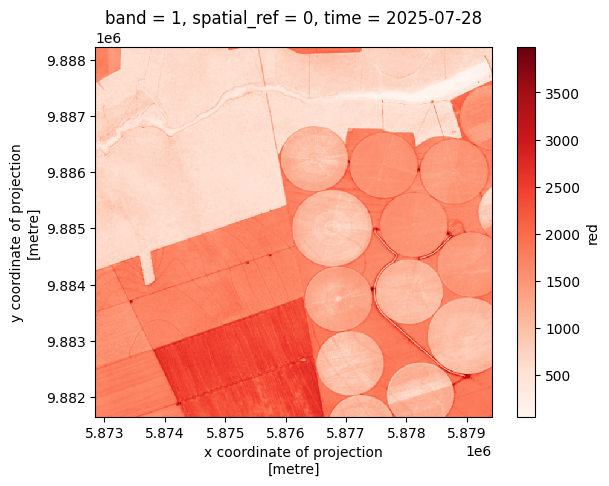

In [11]:
cube["red"].isel(time=0, band=0).plot(cmap="Reds")

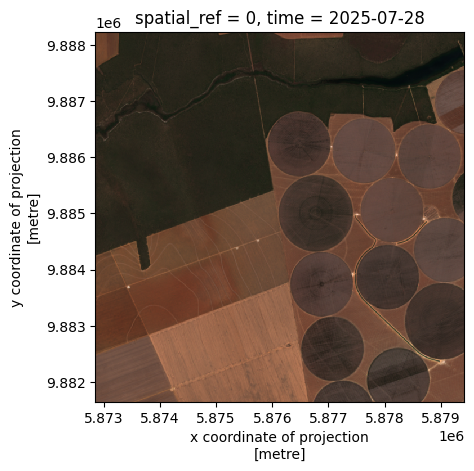

In [12]:
rgb_composition = xr.concat([cube[var].isel(time=0, band=0) for var in variables], dim="band")
rgb_composition = rgb_composition.assign_coords(band=["R", "G", "B"])
rgb_composition = rgb_composition.transpose("y", "x", "band")
rgb_composition = rgb_composition / rgb_composition.max() # normalize

rgb_composition.plot.imshow()
plt.gca().set_aspect('equal')

xarray => numpy (pixels × bandas)

normaliza

treina SOM

encontra BMU (Best Matching Unit)

reshape => imagem

## Normalização dos dados

In [13]:
# stack das bandas → (y, x, features)
stacked = xr.concat([cube[var].isel(time=0, band=0) for var in variables], dim="feature")
stacked = stacked.transpose("y", "x", "feature")

# transformar em (n_pixels, n_features) e normalizar
X = stacked.values.reshape(-1, 3)
norms = np.linalg.norm(X, axis=1, keepdims=True)
X = X / (norms + 1e-8)

## Agrupamento SOM

Compute the size grid following the suggestion proposed by Vesanto et.al.

size_grid_ = list( grid_xdim = jsonlite::unbox(grid_xy), grid_ydim = jsonlite::unbox(grid_xy) )

In [14]:
# número de amostras únicas
n = X.shape[0]

# cálculo do grid (mesma lógica do R)
grid_xy = int(np.sqrt(5 * np.sqrt(n)) - 1)

size_grid_ = {
    "grid_xdim": grid_xy,
    "grid_ydim": grid_xy
}
size_grid_

{'grid_xdim': 56, 'grid_ydim': 56}

In [15]:
grid_xy = 10

som = SOMNetwork(grid_dimensions=(grid_xy, grid_xy), input_dimension=3)

def gaussian_neighbor(xw, yw, x, y, sigma):
    return np.exp(-((x-xw)**2 + (y-yw)**2) / (2*sigma**2))

idx = np.random.choice(len(X), size=50000, replace=False)
X_sample = X[idx]

# treinamento
for epoch in range(5):
    for x in X_sample:
        som.organize(x.reshape(-1,1), eta=0.1, neighbor_fcn=gaussian_neighbor, sigma=2)

image shape:  (10, 10, 3)


Text(0.5, 1.0, 'Trained neural network grid representation')

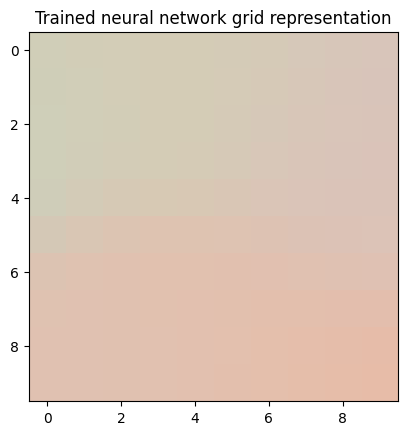

In [16]:
nnet_img_repr_trained = np.zeros((som.grid_dimensions[0], som.grid_dimensions[1], 3), dtype=np.uint8)
print("image shape: ", nnet_img_repr_trained.shape)
#lets convert weight representation to RGB values:
# We must identify the

RGBMAX = 255
for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        #w_norm = np.linalg.norm(my_som_net.neurons[i, j].weights)
        #w_normalized = my_som_net.neurons[i, j].weights/w_norm
        #weight = w_normalized.flatten() #my_som_net.neurons[i, j].weights.flatten()
        weight = som.neurons[i, j].weights.flatten()
        nnet_img_repr_trained[i,j][:] = ((RGBMAX / 2) * (weight + 1)).astype(int)

plt.figure()
plt.imshow(nnet_img_repr_trained)
plt.title("Trained neural network grid representation")

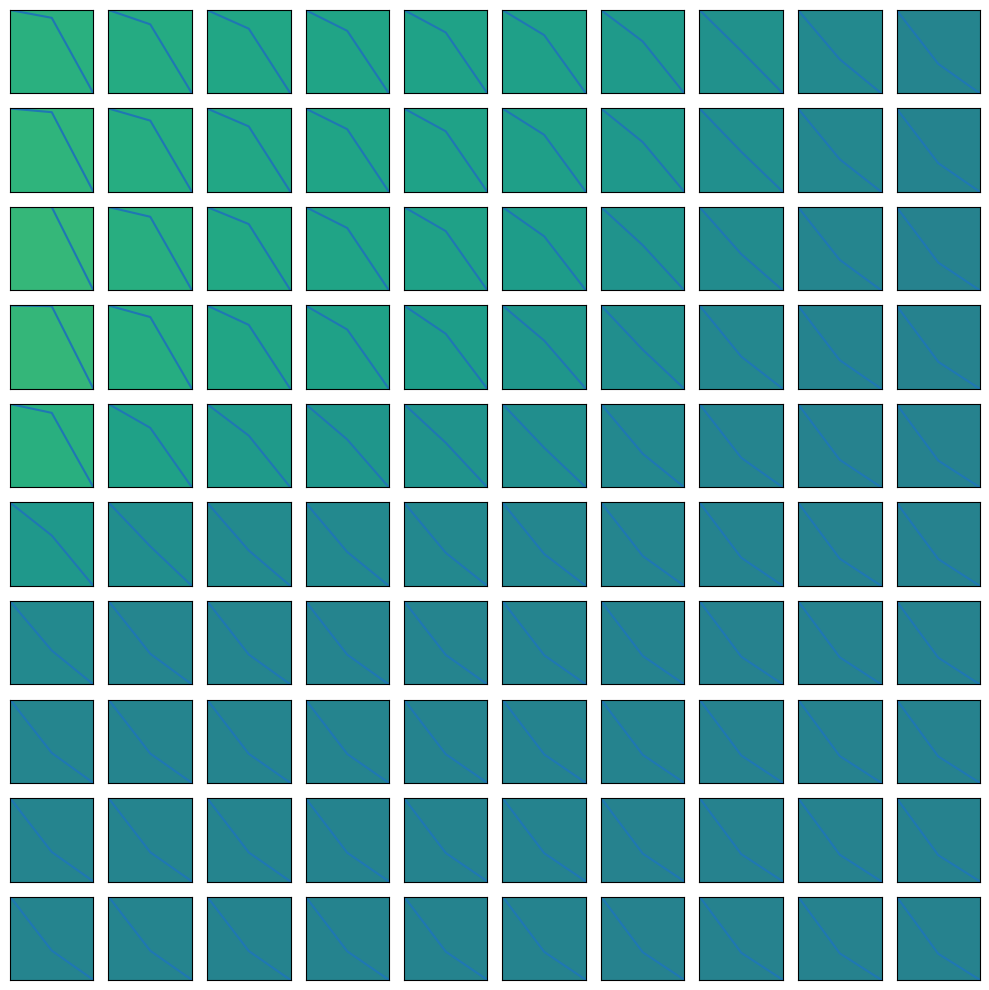

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_som_neurons(som):
    rows, cols = som.grid_dimensions
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            
            # pegar pesos do neurônio
            w = som.neurons[i, j].weights.flatten()

            w = (w - w.min()) / (w.max() - w.min() + 1e-8)
            mean_val = w.mean()
            color = plt.cm.viridis(mean_val)
            ax.set_facecolor(color)
            
            # deixar visual limpo
            ax.set_xticks([])
            ax.set_yticks([])
            
            # opcional: limites fixos (melhora comparação)
            ax.plot(np.linspace(0,1,len(w)), w)
            ax.set_xlim(0,1)
            ax.set_ylim(0,1)
    
    plt.tight_layout()
    plt.show()

plot_som_neurons(som)

In [18]:
labels = []

for x in X:
    activations = np.zeros(som.grid_dimensions)
    
    for i in range(som.grid_dimensions[0]):
        for j in range(som.grid_dimensions[1]):
            activations[i,j] = np.dot(
                x.flatten(),
                som.neurons[i,j].weights.flatten()
            )
    
    winner = np.argmax(activations)
    labels.append(winner)

labels = np.array(labels)

In [19]:
cluster_map = labels.reshape(stacked.shape[0], stacked.shape[1])

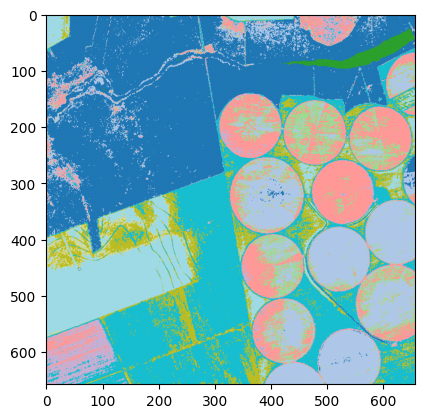

In [20]:
plt.imshow(cluster_map, cmap="tab20")

## Descobrindo as classes:

### K-means:

In [21]:
from sklearn.cluster import KMeans
import numpy as np

# extrair pesos
weights = []
for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        weights.append(som.neurons[i,j].weights.flatten())

weights = np.array(weights)

# clusterizar neurônios
kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(weights)

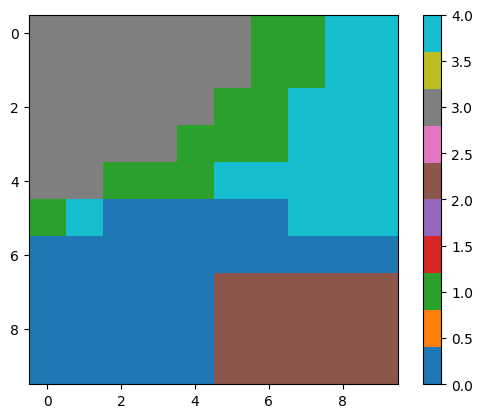

In [22]:
label_map = labels.reshape(som.grid_dimensions)
import matplotlib.pyplot as plt
plt.imshow(label_map, cmap="tab10")
plt.colorbar()

### Agrupamento hierarquico

In [23]:
weights = []
positions = []

for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        weights.append(som.neurons[i,j].weights.flatten())
        positions.append((i, j))

weights = np.array(weights)

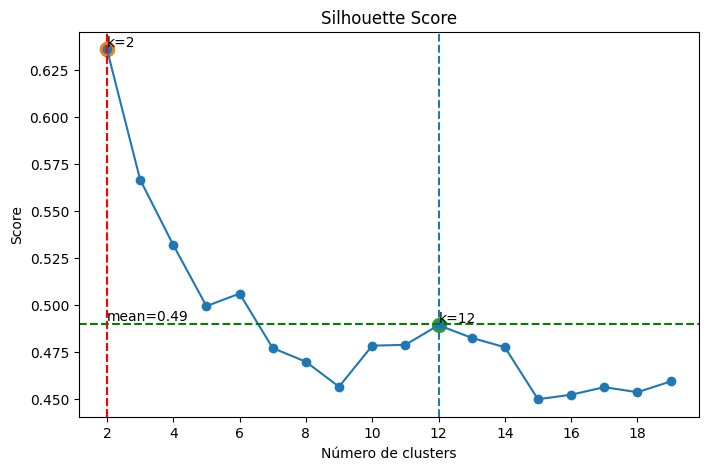

In [78]:
# Silhouette Score (melhor método prático)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

k_range = range(2, 20)
scores = []

for k in k_range:
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(weights, labels)
    scores.append(score)

# melhor k
best_k = k_range[np.argmax(scores)]
best_score = max(scores)

# média
mean_score = np.mean(scores)

# índice do ponto mais próximo da média
idx_closest = np.argmin(np.abs(np.array(scores) - mean_score))

closest_k = k_range[idx_closest]
closest_score = scores[idx_closest]

# plot
plt.figure(figsize=(8,5))
plt.plot(k_range, scores, marker='o')

# melhor k
plt.scatter(best_k, best_score, s=100)
plt.axvline(best_k, linestyle='--', color = "red")

# K próximo da média
plt.scatter(best_k, best_score, s=100)
plt.axvline(best_k, linestyle='--', color = "red")

plt.scatter(closest_k, closest_score, s=100)
plt.axvline(closest_k, linestyle='--')

# média
plt.axhline(mean_score, linestyle='--', color = "green")

# anotação
plt.text(best_k, best_score, f"k={best_k}", ha='left', va='bottom')
plt.text(k_range.start, mean_score, f"mean={mean_score:.2f}", va='bottom')
plt.text(closest_k, closest_score, f"k={closest_k}", ha='left', va='bottom')

plt.title("Silhouette Score")
plt.xlabel("Número de clusters")
plt.ylabel("Score")

plt.xticks(np.arange(min(k_range), max(k_range)+1, 2))
plt.show()

Text(0.5, 1.0, 'Dendrograma dos neurônios')

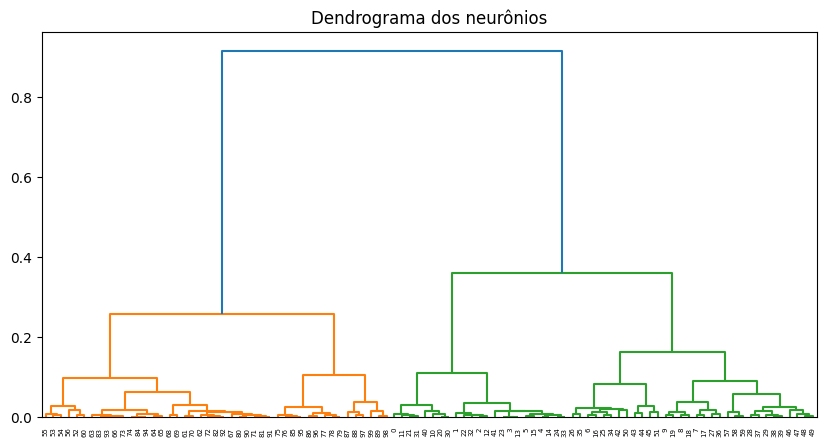

In [62]:
# Não precisa escolher clusters exatos de início
# Permite explorar níveis (2, 3, 5, 10 classes…)
# Funciona muito bem com poucos neurônios

# escolher número de classes
n_classes = best_k
labels = fcluster(Z, n_classes, criterion='maxclust')
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrograma dos neurônios")

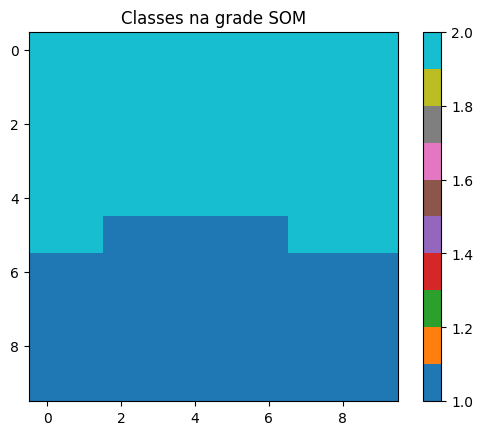

In [63]:
label_map = np.zeros(som.grid_dimensions)

for (i, j), label in zip(positions, labels):
    label_map[i, j] = label


plt.imshow(label_map, cmap="tab10")
plt.title("Classes na grade SOM")
plt.colorbar()
plt.show()

In [64]:
label_map = np.zeros(som.grid_dimensions)

for (i, j), label in zip(positions, labels):
    label_map[i, j] = label

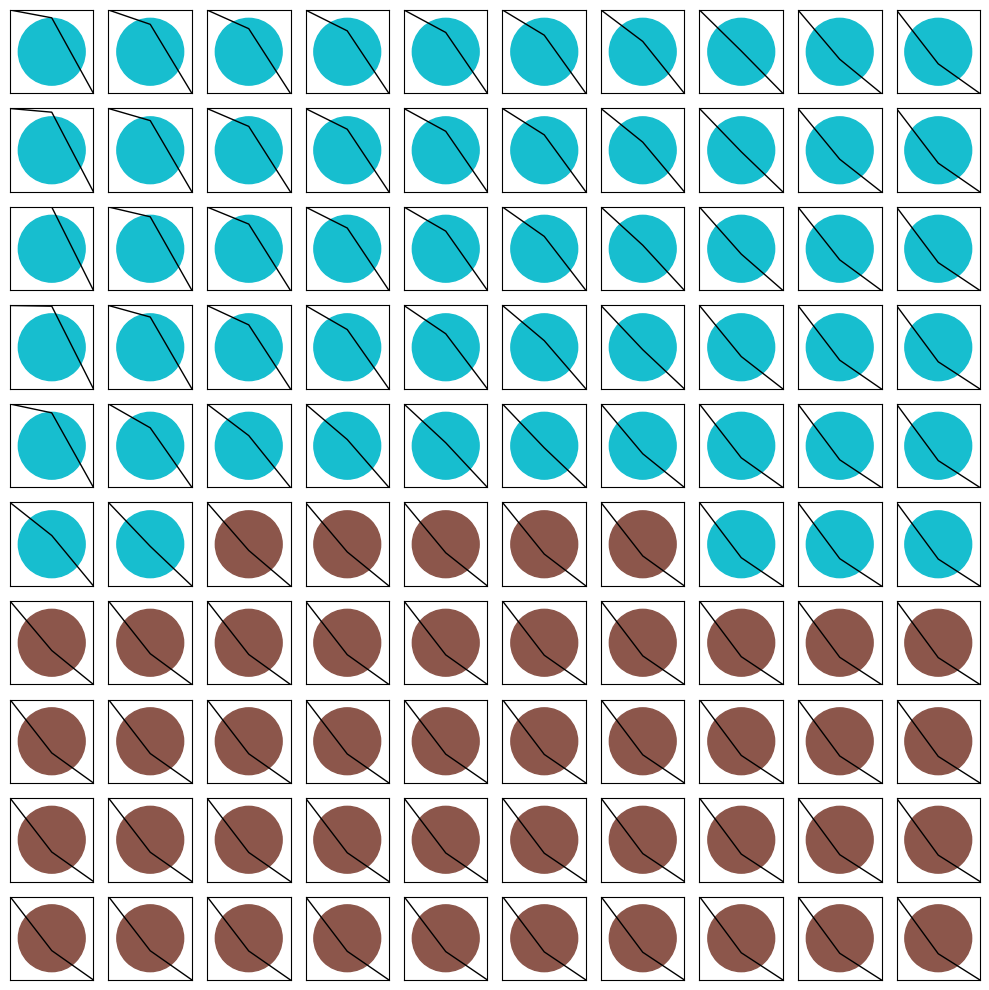

In [65]:
def plot_som_neurons(som, labels):
    rows, cols = som.grid_dimensions
    label_map = labels.reshape(rows, cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            
            # pegar label
            label = int(label_map[i, j])
            color = plt.cm.tab10(label / np.max(label_map))
            
            # desenhar círculo
            circle = plt.Circle((0.5, 0.5), 0.4, color=color)
            ax.add_patch(circle)
            
            # opcional: pesos (assinatura espectral)
            w = som.neurons[i, j].weights.flatten()
            w = (w - w.min()) / (w.max() - w.min() + 1e-8)
            
            ax.plot(np.linspace(0,1,len(w)), w, color="black", linewidth=1)
            
            # estética
            ax.set_xlim(0,1)
            ax.set_ylim(0,1)
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

plot_som_neurons(som, label_map)

SOM organiza padrões no espaço

Hierárquico corta esse espaço em regiões

BMU leva isso para a imagem

Resumo

Com hierárquico você:

agrupa neurônios
define classes na grade

In [66]:
pixel_classes = []

for x in X:
    activations = np.zeros(som.grid_dimensions)

    for i in range(som.grid_dimensions[0]):
        for j in range(som.grid_dimensions[1]):
            activations[i,j] = np.dot(
                x.flatten(),
                som.neurons[i,j].weights.flatten()
            )

    winner = np.argmax(activations)
    pixel_classes.append(labels[winner])

pixel_classes = np.array(pixel_classes)

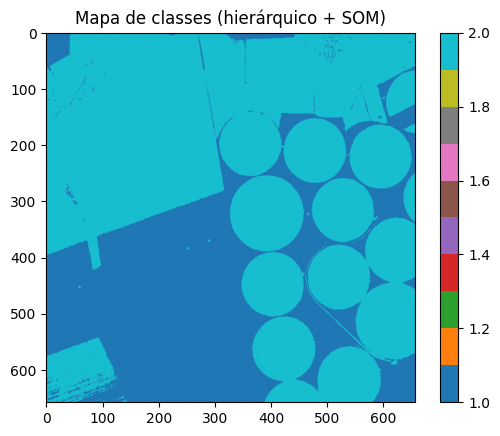

In [67]:
height, width = stacked.shape[0], stacked.shape[1]

cluster_map = pixel_classes.reshape(height, width)

plt.imshow(cluster_map, cmap="tab10")
plt.title("Mapa de classes (hierárquico + SOM)")
plt.colorbar()

### Transformar em polígonos

In [68]:
cluster_da = xr.DataArray(
    cluster_map,
    dims=("y", "x"),
    coords={
        "y": cube["y"],
        "x": cube["x"]
    }
)

cluster_da = cluster_da.rio.write_crs(cube.rio.crs)
transform = cluster_da.rio.transform()

shapes_gen = shapes(
    cluster_da.values.astype("int32"),
    transform=transform
)

geoms = []
vals = []

for geom, value in shapes_gen:
    geoms.append(shape(geom))
    vals.append(value)

gdf = gpd.GeoDataFrame(
    {"class": [int(val) for val in vals]},
    geometry=geoms,
    crs=cluster_da.rio.crs
)

# Combinar polígonos da mesma classe
gdf = gdf.dissolve(by="class")
gdf.to_file("clusters/clusters.shp")
gdf = gdf.reset_index()
gdf = gdf.set_crs(cube.rio.crs)
gdf = gdf.to_crs("EPSG:4326")
gdf

,class,geometry
0,1,"MULTIPOLYGON (((-45.8299 -12.94009, -45.8299 -..."
1,2,"MULTIPOLYGON (((-45.82457 -12.94003, -45.82457..."


<Axes: >

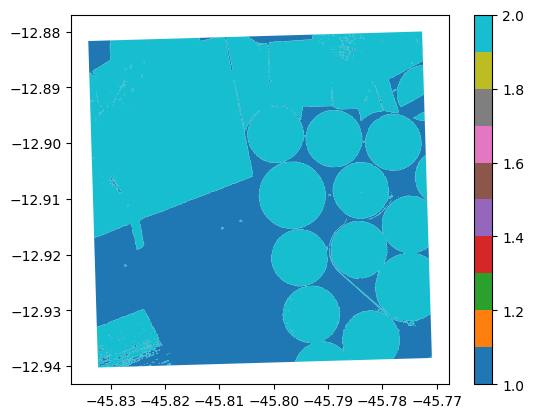

In [69]:
gdf.plot(column="class", cmap="tab10", legend=True)

In [70]:
# Seleciona pontos aleatórios dentro dos polígonos de maior extensão
def sample_points_in_polygons(gdf, n_points_per_polygon = 1, top_n = 1):
    points = []
    class_ = []

    for _, row in gdf.iterrows():
        geom = row.geometry

        # se for multipolygon, ele identifica os top_n maiores
        if isinstance(geom, MultiPolygon):
            polygons = list(geom.geoms)
            
            # ordenar por área (maior → menor)
            polygons = sorted(polygons, key=lambda p: p.area, reverse=True)
            
            # pegar os top N maiores
            polygons = polygons[:top_n]
        else:
            polygons = [geom]

        # Amostrar aleatóriamente em cada polígono selecionado
        for poly in polygons:
            minx, miny, maxx, maxy = poly.bounds
            count = 0

            while count < n_points_per_polygon:
                x = np.random.uniform(minx, maxx)
                y = np.random.uniform(miny, maxy)
                p = Point(x, y)

                if poly.contains(p):
                    points.append(p)
                    class_.append(row['class'])
                    count += 1

    return gpd.GeoDataFrame({'class': class_}, geometry=points, crs=gdf.crs)

samples_selected = sample_points_in_polygons(gdf, 5)
samples_selected.to_file("samples/samples.shp")
samples_selected

,class,geometry
0,1,POINT (-45.78956 -12.90879)
1,1,POINT (-45.81485 -12.91134)
2,1,POINT (-45.80486 -12.91914)
3,1,POINT (-45.78734 -12.91255)
4,1,POINT (-45.78393 -12.89769)
5,2,POINT (-45.82388 -12.90003)
6,2,POINT (-45.78711 -12.88525)
7,2,POINT (-45.79367 -12.90042)
8,2,POINT (-45.80519 -12.89084)
9,2,POINT (-45.81383 -12.90733)


<Axes: >

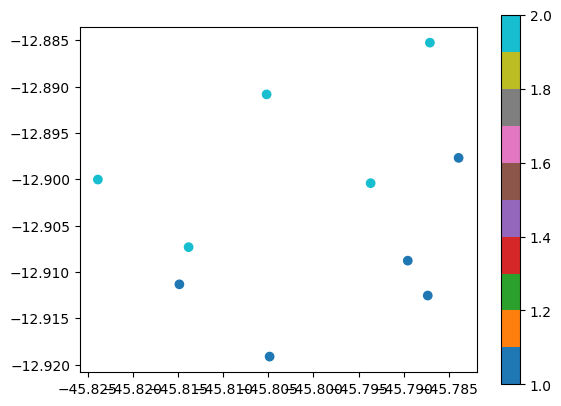

In [71]:
samples_selected.plot(column="class", cmap="tab10", legend=True)

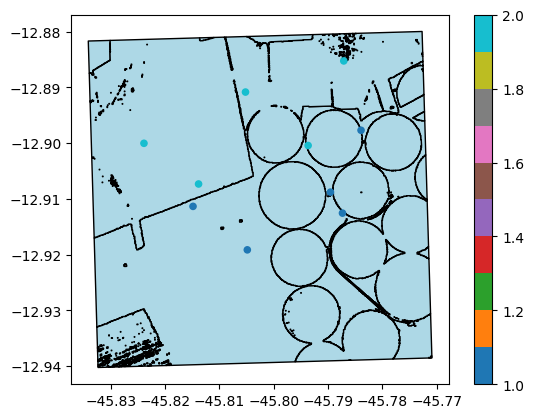

In [72]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

classes = np.unique(gdf["class"])

cmap = plt.cm.tab10
norm = mcolors.Normalize(vmin=classes.min(), vmax=classes.max())

fig, ax = plt.subplots()

# polygons first (background)
gdf.plot(ax=ax, color="lightblue", edgecolor="black")

# points on top
samples_selected.plot(ax=ax, column="class", cmap=cmap, norm=norm, legend=True, markersize=20)

plt.show()

## Gerando padrões por classe

In [122]:
def generate_samples_csv(points_gdf):
    samples = {
        "sample_id": [],
        "label": [],
        "longitude": [],
        "latitude": [],
        "start_date": [],
        "end_date": [],
        "cube": [],
        "time_series": [],
        "trajectory": []
    }    
    for row in range(0, len(points_gdf)):
        samples["sample_id"].append(row + 1)
        samples["label"].append(samples_selected['class'][row])
        samples["longitude"].append(samples_selected.geometry[row].x)
        samples["latitude"].append(samples_selected.geometry[row].y)
        samples["start_date"].append(count_days(date, 190, sub = True))
        samples["end_date"].append(date)
        samples["cube"].append(cube_name)
        samples["time_series"].append({})
        samples["trajectory"].append({})
    return pd.DataFrame(samples).sort_values("sample_id").reset_index(drop=True)

samples_selected_csv = generate_samples_csv(samples_selected)
samples_selected_csv

,sample_id,label,longitude,latitude,start_date,end_date,cube,time_series,trajectory
0,1,1,-45.789557,-12.908788,2025-01-23,2025-08-01,S2-16D-2,{},{}
1,2,1,-45.814850,-12.911343,2025-01-23,2025-08-01,S2-16D-2,{},{}
2,3,1,-45.804858,-12.919143,2025-01-23,2025-08-01,S2-16D-2,{},{}
3,4,1,-45.787344,-12.912553,2025-01-23,2025-08-01,S2-16D-2,{},{}
4,5,1,-45.783927,-12.897694,2025-01-23,2025-08-01,S2-16D-2,{},{}
5,6,2,-45.823878,-12.900030,2025-01-23,2025-08-01,S2-16D-2,{},{}
6,7,2,-45.787106,-12.885253,2025-01-23,2025-08-01,S2-16D-2,{},{}
7,8,2,-45.793668,-12.900423,2025-01-23,2025-08-01,S2-16D-2,{},{}
8,9,2,-45.805192,-12.890837,2025-01-23,2025-08-01,S2-16D-2,{},{}
9,10,2,-45.813827,-12.907327,2025-01-23,2025-08-01,S2-16D-2,{},{}


In [161]:
def make_request_wtss(host, coverage, bands, start, end, longitude, latitude):
    url = (f"{urllib.parse.urljoin(host, f'time_series')}?" +
          f"coverage={coverage}" +
          f"&attributes={",".join(bands)}" +
          f"&start_date={start}" +
          f"&end_date={end}" +
          f"&latitude={latitude}" +
          f"&longitude={longitude}")
    response = requests.get(url).json().get('result', None)
    if response:
        return(json.dumps(response, ensure_ascii=False))
    else:
        return(json.dumps({}, ensure_ascii=False))       
    
def make_request_wlts(host, collections, start, end, longitude, latitude):
    url = (f"{urllib.parse.urljoin(host, f'trajectory')}?" +
          f"collections={",".join(collections)}" +
          f"&start_date={start}" +
          f"&end_date={end}" +
          f"&latitude={latitude}" +
          f"&longitude={longitude}")
    response = requests.get(url).json().get('result', None)
    if response:
        return(json.dumps(response, ensure_ascii=False))
    else:
        return(json.dumps({}, ensure_ascii=False))      


wtss_url = "https://data.inpe.br/bdc/wtss/v4/"
collections = ["terraclass_amazonia","mapbiomas-v10","ibge_cobertura_uso_terra","prodes_mata_atlantica"]

wlts_url = "https://data.inpe.br/bdc/wlts/v1/"
bands = ["NDVI"]

import json
import shapely
import requests
import urllib
from shapely import to_wkt, wkt

for row in range(0, len(samples_selected_csv)):
    start_date = samples_selected_csv['start_date'][row]
    end_date = samples_selected_csv['end_date'][row]
    longitude = samples_selected_csv['longitude'][row]
    latitude = samples_selected_csv['latitude'][row]
    samples_selected_csv.loc[row, 'time_series'] = make_request_wtss(wtss_url, cube_name, bands, start_date, end_date, longitude, latitude)
    samples_selected_csv.loc[row, 'trajectory'] = make_request_wlts(wlts_url, collections, count_days(start_date, 700, sub = True), end_date, longitude, latitude)
samples_selected_csv

,sample_id,label,longitude,latitude,start_date,end_date,cube,time_series,trajectory
0,1,1,-45.789557,-12.908788,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Soja"", ""collection""..."
1,2,1,-45.814850,-12.911343,2025-01-23,2025-08-01,S2-16D-2,"{""attributes"": [{""attribute"": ""NDVI"", ""values""...","{""trajectory"": [{""class"": ""Mosaico de Usos"", ""..."
2,3,1,-45.804858,-12.919143,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Mosaico de Usos"", ""..."
3,4,1,-45.787344,-12.912553,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Soja"", ""collection""..."
4,5,1,-45.783927,-12.897694,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Soja"", ""collection""..."
5,6,2,-45.823878,-12.900030,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Formação Savânica"",..."
6,7,2,-45.787106,-12.885253,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Formação Savânica"",..."
7,8,2,-45.793668,-12.900423,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Soja"", ""collection""..."
8,9,2,-45.805192,-12.890837,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Formação Savânica"",..."
9,10,2,-45.813827,-12.907327,2025-01-23,2025-08-01,S2-16D-2,{},"{""trajectory"": [{""class"": ""Formação Savânica"",..."
